In [20]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
import seaborn as sns 
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier,plot_tree
import plotly.ex as plt

In [11]:
df= pd.read_csv("diabetes.csv")

In [12]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [16]:
x= df.drop("Outcome", axis=1)
y= df["Outcome"]
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size= 0.2, random_state=42 )
dt = DecisionTreeClassifier(criterion = 'entropy', random_state= 42, max_depth=3)
dt.fit(x_train, y_train)
y_pred= dt.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7662337662337663
              precision    recall  f1-score   support

           0       0.81      0.84      0.82        99
           1       0.69      0.64      0.66        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.76       154



[Text(0.5, 0.875, 'Glucose <= 127.5\nentropy = 0.931\nsamples = 614\nvalue = [401, 213]'),
 Text(0.25, 0.625, 'Age <= 28.5\nentropy = 0.712\nsamples = 390\nvalue = [314, 76]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'BMI <= 30.95\nentropy = 0.391\nsamples = 221\nvalue = [204, 17]'),
 Text(0.0625, 0.125, 'entropy = 0.068\nsamples = 124\nvalue = [123, 1]'),
 Text(0.1875, 0.125, 'entropy = 0.646\nsamples = 97\nvalue = [81, 16]'),
 Text(0.375, 0.375, 'BMI <= 26.35\nentropy = 0.933\nsamples = 169\nvalue = [110, 59]'),
 Text(0.3125, 0.125, 'entropy = 0.191\nsamples = 34\nvalue = [33, 1]'),
 Text(0.4375, 0.125, 'entropy = 0.986\nsamples = 135\nvalue = [77, 58]'),
 Text(0.75, 0.625, 'BMI <= 29.95\nentropy = 0.964\nsamples = 224\nvalue = [87, 137]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Glucose <= 145.5\nentropy = 0.895\nsamples = 61\nvalue = [42, 19]'),
 Text(0.5625, 0.125, 'entropy = 0.533\nsamples = 33\nvalue = [29, 4]'),
 Text(0.6875, 0.125, 'entropy = 0.996\nsampl

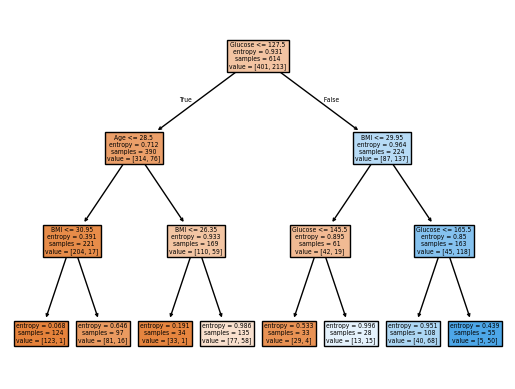

In [17]:
plot_tree(dt, feature_names= x.columns , filled=True)

1 0.7402597402597403
2 0.7727272727272727
3 0.7662337662337663
4 0.7142857142857143
5 0.7857142857142857
6 0.7402597402597403
7 0.7402597402597403
8 0.7662337662337663
9 0.7662337662337663
10 0.7402597402597403
11 0.7207792207792207
12 0.7272727272727273
13 0.7337662337662337
14 0.7077922077922078
15 0.7142857142857143
16 0.7207792207792207
17 0.7207792207792207
18 0.7207792207792207
19 0.7207792207792207
20 0.7207792207792207
21 0.7207792207792207
22 0.7207792207792207
23 0.7207792207792207
24 0.7207792207792207
25 0.7207792207792207
26 0.7207792207792207
27 0.7207792207792207
28 0.7207792207792207
29 0.7207792207792207
30 0.7207792207792207
31 0.7207792207792207
32 0.7207792207792207
33 0.7207792207792207
34 0.7207792207792207
35 0.7207792207792207
36 0.7207792207792207
37 0.7207792207792207
38 0.7207792207792207
39 0.7207792207792207
40 0.7207792207792207
41 0.7207792207792207
42 0.7207792207792207
43 0.7207792207792207
44 0.7207792207792207
45 0.7207792207792207
46 0.72077922077922

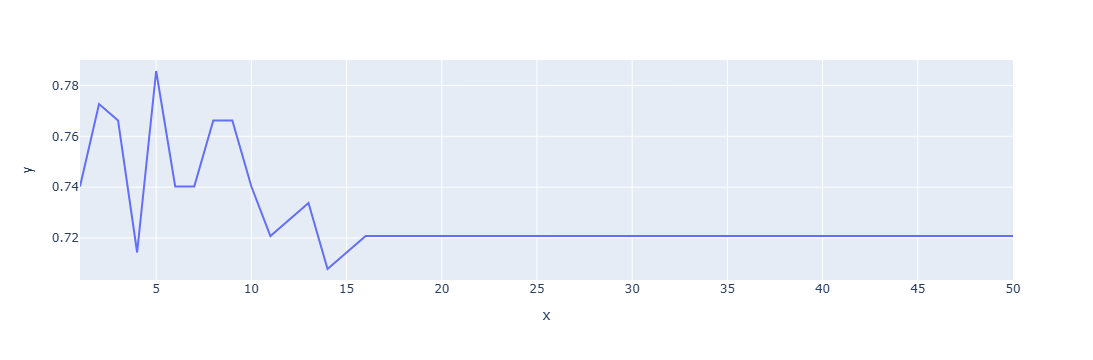

In [22]:
mx= 0
l=[]
for i in range(1,51):
    dt = DecisionTreeClassifier(criterion = 'entropy', random_state= 42, max_depth=i)
    dt.fit(x_train, y_train)
    y_pred= dt.predict(x_test)
    acc= accuracy_score(y_test, y_pred)
    if acc>mx:
        mx =acc
        idx= i 
    print(i , acc)
    l.append(acc)
print(idx ,  mx)
ii= [i for i in range(1,51)]
plt.line(x=ii,y=l )